# GeoDetective — Playground (single debug)

Notebook interactiva para correr el agente sobre **una foto a la vez**, con prompt/modelo/steps editables. Output síncrono — esperás y ves todo al final.

**Flujo**:
1. Setup (imports, .env, corpus)
2. Browse corpus → elegir foto
3. Configurar modelo + prompt + steps
4. Run (bloqueante, 5-15 min según `max_steps`)
5. Inspect: outcome, mapa, tools, trayectoria

## 1. Setup

In [1]:
import json
import os
import sys
import time
from pathlib import Path

import pandas as pd
from IPython.display import Image, display
from geopy.distance import geodesic

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

# Load .env (formato KEY=VALUE)
for line in (ROOT / ".env").read_text().splitlines():
    if "=" in line and not line.startswith("#"):
        k, _, v = line.partition("=")
        os.environ[k.strip()] = v.strip()

# Corpus canónico (151 fotos)
corpus = json.loads(
    (ROOT / "experiments/E007_sample_diverso/candidates_v2_final.json").read_text(encoding="utf-8")
)
df = pd.DataFrame(corpus)
print(f"Corpus: {len(df)} fotos")
print(f"Países top: {df['country'].value_counts().head(8).to_dict()}")
print(f"Buckets: {df['bucket_pais'].value_counts().to_dict()}")

Corpus: 151 fotos
Países top: {'China': 16, 'Russia': 15, 'USA': 14, 'United Kingdom': 9, 'Israel': 7, 'Australia': 7, 'New Zealand': 6, 'Denmark': 6}
Buckets: {'Asia-non-URSS': 24, 'LatinoAmerica': 22, 'Africa-ME': 17, 'Oceania': 15, 'Norteamerica': 15, 'Ex-URSS': 11, 'Europa-Britanica': 9, 'Europa-Nordica': 8, 'Russia-Asia': 8, 'Russia-EU': 7, 'Europa-Occidental': 6, 'Europa-Mediterranea': 5, 'Europa-CentroEste': 4}


## 2. Browse + pick photo

`pick_photo(cid=..., idx=..., country=..., year_range=(a,b))`. Sin args: lista las primeras 20 del filtro.

In [2]:
def pick_photo(cid=None, idx=None, country=None, year_range=None, show=True):
    sub = df
    if country:
        sub = sub[sub["country"].str.contains(country, case=False, na=False)]
    if year_range:
        sub = sub[(sub["year"] >= year_range[0]) & (sub["year"] <= year_range[1])]

    if cid is not None:
        rows = sub[sub["cid"] == cid]
        if rows.empty:
            print(f"cid {cid} no está en el filtro")
            return None
        rec = rows.iloc[0].to_dict()
    elif idx is not None:
        if idx >= len(sub):
            print(f"idx {idx} fuera de rango (filtro tiene {len(sub)})")
            return None
        rec = sub.iloc[idx].to_dict()
    else:
        print(f"Filtro: {len(sub)} fotos. Pasá idx o cid.")
        display(sub[["cid", "country", "year", "bucket_pais", "bucket_decada"]].head(20))
        return None

    if show:
        img_path = ROOT / f"corpus/photos/{rec['cid']}_clean_v1.jpg"
        if img_path.exists():
            display(Image(filename=str(img_path), width=600))
        else:
            print(f"⚠️  Foto no encontrada localmente: {img_path}")
            print("Corré: python scripts/download_corpus_photos.py experiments/E007_sample_diverso/candidates_v2_final.json")
        print(f"cid={rec['cid']}  country={rec['country']}  year={rec.get('year')}  geo={rec['geo']}")
        print(f"bucket={rec['bucket_pais']}/{rec['bucket_decada']}")
    return rec

# Ejemplo: lista 20 fotos
pick_photo()

Filtro: 151 fotos. Pasá idx o cid.


,cid,country,year,bucket_pais,bucket_decada
0,296448,Iraq,1925,Asia-non-URSS,1920s
1,370177,Poland,1905,Europa-CentroEste,1900s
2,1425411,New Zealand,1900,Oceania,1900s
3,1140232,Sweden,1916,Europa-Nordica,1910s
4,1423370,Egypt,1895,Africa-ME,1890s
5,1425423,New Zealand,1895,Oceania,1890s
6,348688,Russia,1935,Russia-Asia,1930s
7,426514,USA,1907,Norteamerica,1900s
8,2362399,United Kingdom,1910,Europa-Britanica,1910s
9,2353695,Jamaica,1920,LatinoAmerica,1920s


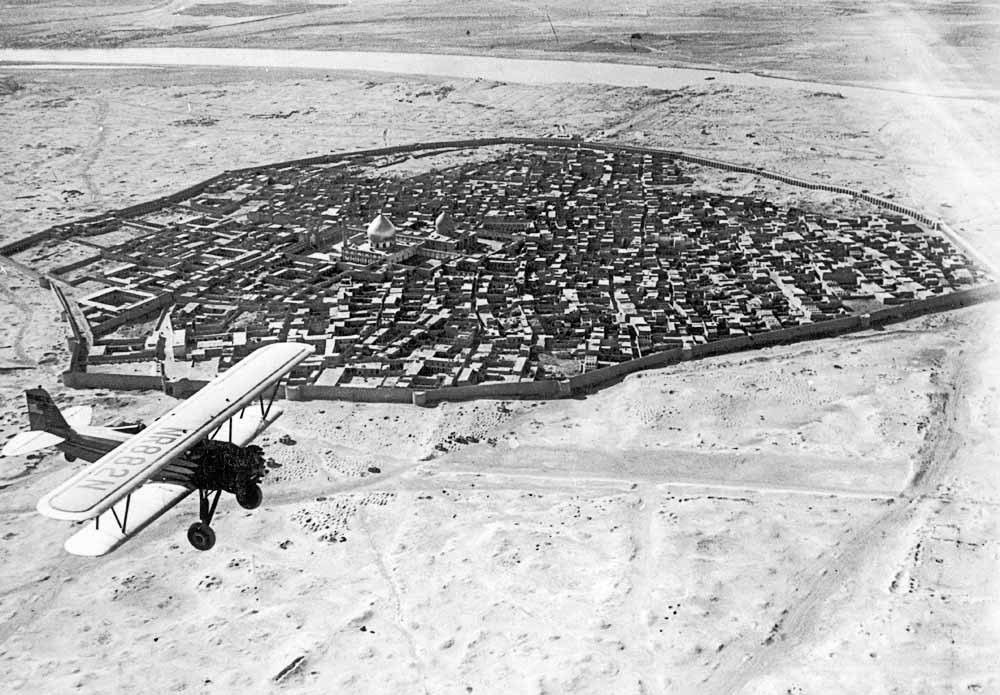

cid=296448  country=Iraq  year=1925  geo=[34.20268, 43.877484]
bucket=Asia-non-URSS/1920s


In [3]:
# Elegí foto (editá esta cell):
photo = pick_photo(idx=0)
# Otros ejemplos:
# photo = pick_photo(cid=2126812)
# photo = pick_photo(country="Russia", year_range=(1900, 1920))  # primero lista
# photo = pick_photo(country="Russia", idx=0)                     # después idx

## 3. Configurar modelo + prompt + steps

`SYSTEM_PROMPT_CUSTOM` arranca igual al canónico. Editalo para iterar.

In [4]:
from geodetective.agents.react import SYSTEM_PROMPT, run_react_agent

MODEL = "gpt-5.4-mini"          # gpt-5.4, gpt-4o, claude-sonnet-4-6, claude-opus-4-6, kimi-k2.5, etc
MAX_STEPS = 20
MIN_STEPS = 0                     # >0 fuerza al agente a investigar más
USER_PROMPT = "Investigá esta foto y devolvé las coordenadas (lat, lon) y año con submit_answer."

# Editá esto para tunear el system prompt. Arranca = al canónico v3.
SYSTEM_PROMPT_CUSTOM = SYSTEM_PROMPT

print(f"MODEL={MODEL}  MAX_STEPS={MAX_STEPS}  MIN_STEPS={MIN_STEPS}")
print(f"system_prompt: {len(SYSTEM_PROMPT_CUSTOM)} chars")
print(f"primeras 300:\n{SYSTEM_PROMPT_CUSTOM[:300]}...")

MODEL=gpt-5.4-mini  MAX_STEPS=20  MIN_STEPS=0
system_prompt: 10570 chars
primeras 300:
Recibís una fotografía histórica. Tu tarea: descubrir DÓNDE fue tomada (coords lat/lon) y CUÁNDO (año aproximado). Cerrá con `submit_answer`.

## Herramientas disponibles

NO te decimos CUÁNDO usar cada una. Vos decidís según el caso. Sí te explicamos exactamente QUÉ hace cada una y QUÉ INFO DEVUELV...


## 4. Run (bloqueante)

Con `verbose=True` ves los prints del agente paso a paso (no es streaming pero ves progreso).

In [5]:
assert photo is not None, "Elegí una foto en la cell 2 primero"
img_path = ROOT / f"corpus/photos/{photo['cid']}_clean_v1.jpg"
assert img_path.exists(), f"Foto no encontrada: {img_path}"

t0 = time.time()
result = run_react_agent(
    image_path=img_path,
    model=MODEL,
    max_steps=MAX_STEPS,
    min_steps=MIN_STEPS,
    verbose=True,
    user_prompt=USER_PROMPT,
    system_prompt=SYSTEM_PROMPT_CUSTOM,
    provider=photo.get("provider"),
    provenance_source=photo.get("provenance_source"),
)
elapsed = time.time() - t0
print(f"\n=== DONE en {elapsed:.0f}s — terminal_state={result.terminal_state} steps={result.steps_used}")

[run_react_agent] model=gpt-5.4-mini provider=openai
[run_react_agent] excluded_domains per-photo: ['pastvu.com']

--- Step 1/20 ---
[assistant] Veo una ciudad amurallada en medio del desierto, con una gran cúpula/mausoleo muy prominente y un avión antiguo en primer plano. Eso me hace pensar en el oasis fortificado de **Chinguetti/Uadane en Mauritania** o alguna ciudad histórica similar del Sahara; voy a buscar comparaciones visuales y señal
  ⚙ image_search({"query": "aerial photo walled city desert large dome mosque oasis Mauritania historical", "max_results": 8})
     → GRID search_id=a951e4d44be7 page=1/1 1 cells target_match=0 suspicious=0
  ⚙ web_search({"query": "\"walled city\" desert large dome aerial historical photo Mauritania oasis", "max_results": 5})
     → 5 results (filtered 4/11)
  ⚙ image_search({"query": "old aerial photo desert walled town mosque dome oasis Sahara", "max_results": 8})
     → GRID search_id=eba82546e692 page=1/1 1 cells target_match=0 suspicious=0

-

## 5. Inspect

In [6]:
# Summary + outcome
print("=== OUTCOME ===")
print(f"terminal_state: {result.terminal_state}")
print(f"steps_used:     {result.steps_used} / {MAX_STEPS}")
print(f"final_answer:   {result.final_answer}")

pred = None
dist_km = None
if result.final_answer:
    lat = result.final_answer.get("lat")
    lon = result.final_answer.get("lon")
    if lat is not None and lon is not None:
        pred = (float(lat), float(lon))
        gt = tuple(photo["geo"])
        dist_km = geodesic(pred, gt).km
        year_pred = result.final_answer.get("year")
        year_gt = photo.get("year")

        def parse_year(y):
            """Acepta int, float, str ('1930'), str-rango ('1930-1950'), None."""
            import re
            if y is None:
                return None
            if isinstance(y, (int, float)):
                return float(y)
            s = str(y).strip()
            m = re.match(r"(\d{4})\s*[-–]\s*(\d{4})", s)
            if m:
                return (int(m.group(1)) + int(m.group(2))) / 2  # promedio del rango
            m = re.search(r"(\d{4})", s)
            if m:
                return float(m.group(1))
            return None

        yp = parse_year(year_pred)
        yg = parse_year(year_gt)
        year_err = abs(yp - yg) if (yp is not None and yg is not None) else None

        print(f"\nGT:    {gt}, year={year_gt}, country={photo['country']}")
        print(f"pred:  {pred}, year={year_pred}  (parsed={yp})")
        print(f"📏 distance: {dist_km:.1f} km")
        print(f"📅 year_err: {year_err}")

print("\n=== TOOL USAGE ===")
for attr in ["web_search_count", "fetch_url_count", "image_search_count", "geocode_count",
             "historical_query_count", "crop_count", "static_map_count", "street_view_count"]:
    n = getattr(result, attr, 0)
    print(f"  {attr:24}: {n}")


=== OUTCOME ===
terminal_state: submitted
steps_used:     6 / 20
final_answer:   {'location': 'Ksar de Chinguetti (mezquita de Chinguetti), Adrar, Mauritania', 'lat': 20.4548623, 'lon': -12.3636545, 'year': '1960-1970', 'reasoning': 'La imagen muestra una ciudad-oasis fortificada en pleno desierto, con tejido urbano muy denso, muralla perimetral y una gran mezquita de cúpula/minarete central. Eso coincide con Chinguetti, Mauritania: la mezquita de Chinguetti está documentada en Aerial Views y en mapas como el núcleo del ksar. El patrón urbano y la relación con dunas alrededor encajan con el mapa satelital/híbrido actual del lugar.', 'confidence': 'alta', 'visual_clues': ['Ciudad amurallada en medio del desierto', 'Tejido urbano compacto de casas bajas de adobe/stone', 'Gran edificio religioso central dominante', 'Paisaje de dunas y planicie árida alrededor', 'Toma aérea oblicua en blanco y negro con avión de hélice, consistente con foto histórica de mediados del siglo XX'], 'external_e

In [7]:
# Mapa folium: pred (rojo) vs ground truth (verde)
import folium

gt = tuple(photo["geo"])
if pred is not None:
    center = [(gt[0] + pred[0]) / 2, (gt[1] + pred[1]) / 2]
    # zoom según distancia: muy cerca → zoom alto, muy lejos → zoom bajo
    zoom = 12 if dist_km < 5 else (10 if dist_km < 50 else (7 if dist_km < 500 else (4 if dist_km < 5000 else 2)))
else:
    center = list(gt)
    zoom = 6

m = folium.Map(location=center, zoom_start=zoom)
folium.Marker(
    list(gt),
    popup=f"<b>Ground truth</b><br>{photo['country']} {photo.get('year')}<br>cid={photo['cid']}",
    icon=folium.Icon(color="green", icon="ok-sign"),
).add_to(m)
if pred is not None:
    folium.Marker(
        list(pred),
        popup=f"<b>Predicción {MODEL}</b><br>distance: {dist_km:.1f} km",
        icon=folium.Icon(color="red", icon="flag"),
    ).add_to(m)
    folium.PolyLine([list(gt), list(pred)], color="#888", weight=2, dash_array="5,5").add_to(m)

m

In [8]:
# Trayectoria simplificada: thinking + tool calls
def short(s, n=180):
    s = str(s)
    return s if len(s) <= n else s[:n] + "..."

print("=== TRAYECTORIA ===")
for ev in result.trace:
    step = ev.get("step", "?")
    t = ev.get("type", "?")

    if t == "thinking":
        c = ev.get("content", "")
        if c:
            print(f"[{step:>2}] 💭 {short(c, 300)}")
    elif t == "tool_call":
        args = ev.get("arguments", {})
        try:
            args_str = json.dumps(args, ensure_ascii=False)
        except Exception:
            args_str = str(args)
        print(f"[{step:>2}] 🔧 {ev.get('name', '?')}({short(args_str, 140)})")
    elif t == "web_search":
        results = ev.get("results", [])
        top = results[0].get("title", "") if results else "(0 results)"
        print(f"[{step:>2}]   → web_search: {len(results)} hits, top: {short(top, 80)}")
    elif t == "geocode":
        results = ev.get("results", [])
        print(f"[{step:>2}]   → geocode: {len(results)} hits")
    elif t == "fetch_url":
        print(f"[{step:>2}]   → fetch_url: {short(ev.get('url', ''), 100)}")
    elif t == "image_search":
        print(f"[{step:>2}]   → image_search: {ev.get('num_results', '?')} results")
    elif t == "static_map":
        print(f"[{step:>2}]   → static_map @ {ev.get('center', '?')}")
    elif t == "street_view":
        print(f"[{step:>2}]   → street_view @ {ev.get('location', '?')}")
    elif t == "crop_image":
        print(f"[{step:>2}]   → crop_image {ev.get('region', '?')}")
    elif t == "historical_query":
        print(f"[{step:>2}]   → historical_query: {short(ev.get('summary', ''), 100)}")
    elif "error" in t:
        print(f"[{step:>2}] ❌ {t}: {short(ev.get('error', ''), 100)}")

=== TRAYECTORIA ===
[ 1] 💭 Veo una ciudad amurallada en medio del desierto, con una gran cúpula/mausoleo muy prominente y un avión antiguo en primer plano. Eso me hace pensar en el oasis fortificado de **Chinguetti/Uadane en Mauritania** o alguna ciudad histórica similar del Sahara; voy a buscar comparaciones visuales y señal...
[ 1]   → image_search: ? results
[ 1]   → web_search: 0 hits, top: (0 results)
[ 1]   → image_search: ? results
[ 2] 💭 La búsqueda por imágenes no está ayudando, así que paso a fuentes textuales de sitios sobre ksour mauritanos. La combinación “murallas de adobe, oasis, gran cúpula/mausoleo” sigue apuntando fuerte a **Chinguetti** o **Ouadane**; voy a buscar qué ciudad tiene una cúpula tan destacada en fotos históri...
[ 2]   → web_search: 0 hits, top: (0 results)
[ 2]   → web_search: 0 hits, top: (0 results)
[ 2]   → web_search: 0 hits, top: (0 results)
[ 3] 💭 Chinguetti queda más fuerte que Ouadane: la foto muestra una ciudad muy compacta, rectangular/ovalada

---

### Tips

- Para correr otra foto: editá la cell de `pick_photo(...)` y vuelve a correr desde ahí.
- Para cambiar prompt: editá `SYSTEM_PROMPT_CUSTOM` y re-corré desde la cell 3.
- Para cambiar modelo: editá `MODEL` y re-corré desde la cell 3.
- El trace completo está en `result.trace` (list of dicts). Para análisis más profundo:
  - `result.trace[N]` — evento N
  - `[ev['type'] for ev in result.trace]` — secuencia de tipos
  - `[ev for ev in result.trace if ev.get('type') == 'thinking']` — solo thinking blocks